# Binance perps — correlation analysis

Question: do **pre-existing exchange footprint** and **funding background** predict **post-launch perp performance** (price + volume)?

Data: `enriched_clean.csv` (built by `build_enriched.py`, then cleaned by `clean_enriched.py`). Each row = one Binance-perp launch.

Sections:
1. Load + sanity
2. Univariate distributions
3. CryptoRank vs RootData agreement on funding
4. Spearman correlation matrix
5. Targeted slices
6. OLS effect-size ranking
7. Findings


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('enriched_clean.csv', parse_dates=['binance_perp_date'])
print('rows:', len(df))
df.head()

## 1. Sanity — null rates & coverage

In [2]:
null_rates = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print('Null rate %:')
print(null_rates[null_rates > 0])

Null rate %:
cr_ico_raised_usd           98.6
rd_total_funding_usd        40.1
funding_consensus_usd       39.8
days_since_first_listing    28.2
cr_has_funding_rounds       25.9
cr_fdv                      25.9
cr_slug                     25.9
rd_rt_score                  9.2
rd_establishment_date        5.5
vol_decay_ratio              4.3
fdv_at_listing               2.9
rd_project_id                1.4
ret_30d                      1.4
vol_avg_d8_30_usd            1.4
avg_funding_rate_30d         0.9
ret_7d                       0.9
vol_avg_d2_7_usd             0.9
vol_d1_usd                   0.9
max_drawdown_30d             0.9
ret_1d                       0.9
perp_symbol                  0.6
cr_investor_count            0.3
cr_lead_count                0.3
rd_investor_count            0.3
rd_lead_count                0.3
cr_tier1_count               0.3
dtype: float64


In [3]:
# drop rows with no kline data (delisted/illiquid perps)
has_perp = df['ret_7d'].notna()
print(f'with kline data: {has_perp.sum()}/{len(df)}')
core = df[has_perp].copy()

with kline data: 344/347


## 2. Univariate distributions

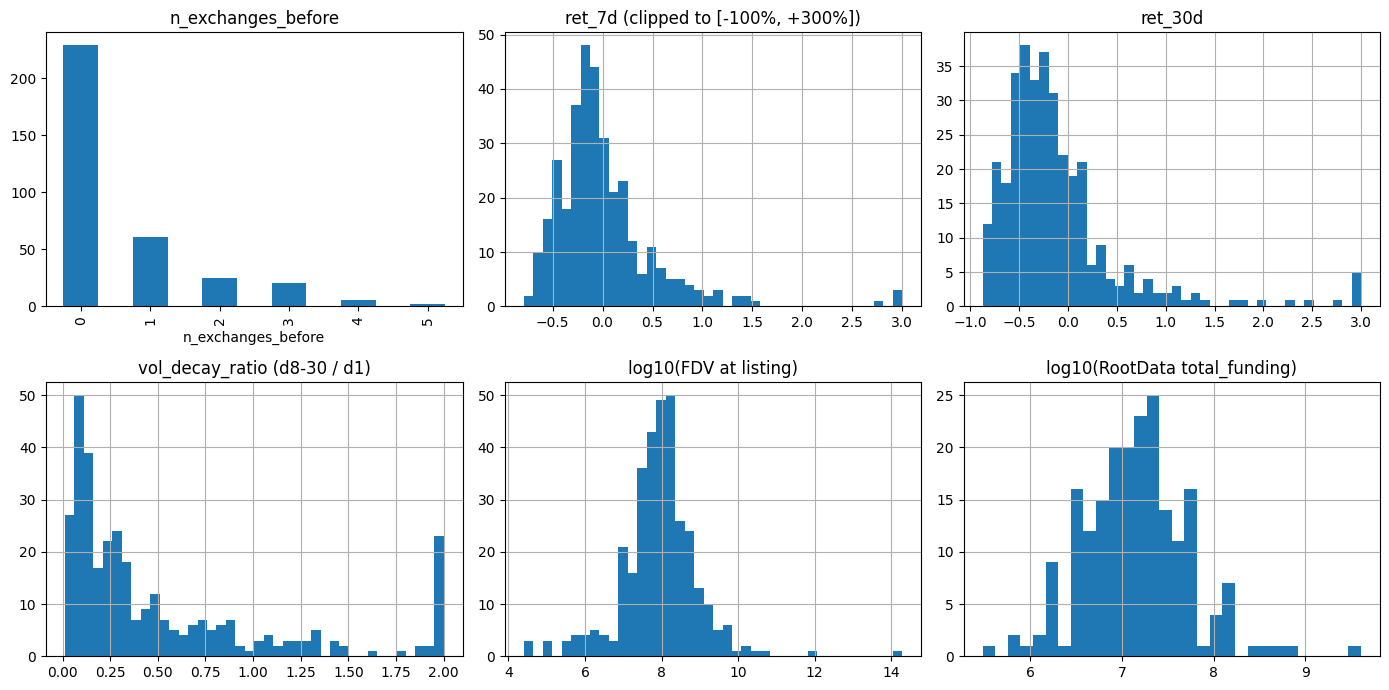

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
core['n_exchanges_before'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], title='n_exchanges_before')
core['ret_7d'].clip(-1, 3).hist(bins=40, ax=axes[0,1]); axes[0,1].set_title('ret_7d (clipped to [-100%, +300%])')
core['ret_30d'].clip(-1, 3).hist(bins=40, ax=axes[0,2]); axes[0,2].set_title('ret_30d')
core['vol_decay_ratio'].clip(0, 2).hist(bins=40, ax=axes[1,0]); axes[1,0].set_title('vol_decay_ratio (d8-30 / d1)')
np.log10(core['fdv_at_listing'].dropna()).hist(bins=40, ax=axes[1,1]); axes[1,1].set_title('log10(FDV at listing)')
np.log10(core['rd_total_funding_usd'].replace(0, np.nan).dropna()).hist(bins=30, ax=axes[1,2])
axes[1,2].set_title('log10(RootData total_funding)')
plt.tight_layout(); plt.show()

### How to read Chart 1 (the 2×3 distributions grid)

Six little charts in one image — they answer the question "what does our raw data even look like before we start measuring relationships?"

- **Top-left: `n_exchanges_before` bars.** Each bar's height = how many tokens fall in that bucket (0 prior listings, 1, 2, ...). You can see most tokens had 0–2 prior venues — pure greenfield launches are common.
- **Top-middle: `ret_7d` histogram.** X-axis is return over the first week (`0` = flat, `1` = +100%, `-0.5` = −50%). The bulk sits between −50% and 0%, with a few outlier winners stretching right. Clipped at ±300% so one mega-pump doesn't squash the rest.
- **Top-right: `ret_30d` histogram.** Same idea but 30-day return. Notice the mass shifts left vs 7d — most perps drift lower over a month.
- **Bottom-left: `vol_decay_ratio` histogram.** `1.0` means volume on days 8–30 equals day-1; under `1.0` means volume faded. The peak is clearly below 1 — most launches lose interest fast.
- **Bottom-middle: log10(FDV).** Tokens span roughly 10^5 ($100k) to 10^10 ($10B). Roughly symmetric on the log scale, so the underlying FDV is heavy-tailed.
- **Bottom-right: log10(RootData funding).** Also log-scale. Most projects that have any funding info raised $1M–$100M.

**Takeaway:** the returns and volume distributions are long-tailed and slightly negative on average. Money columns are heavy-tailed (a few giants, many small ones) — that's why we'll use Spearman ranks instead of raw values for the correlations.


## 3. CryptoRank vs RootData — funding agreement
Note: CryptoRank v0's `icoData.raised.USD` is the **public-sale** amount only, while RootData's `total_funding` aggregates **all rounds**. They should correlate but RD will usually be larger.

In [ ]:
both = core[core['cr_ico_raised_usd'].notna() & core['rd_total_funding_usd'].notna() & (core['rd_total_funding_usd']>0)]
print(f'both sources present: {len(both)}')
print(core['funding_match'].value_counts())
# Always render the scatter — sparsity itself is the finding.
plt.figure(figsize=(6,6))
if len(both) > 0:
    plt.scatter(both['cr_ico_raised_usd'], both['rd_total_funding_usd'], alpha=0.7, s=80)
    lim_lo = min(both['cr_ico_raised_usd'].min(), both['rd_total_funding_usd'].min()) * 0.5
    lim_hi = max(both['cr_ico_raised_usd'].max(), both['rd_total_funding_usd'].max()) * 2
    plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.3, label='y = x')
    plt.legend()
    if len(both) >= 5:
        rho, p = stats.spearmanr(both['cr_ico_raised_usd'], both['rd_total_funding_usd'])
        plt.title(f'Funding: CR ICO sale vs RD all-rounds  (ρ={rho:.2f}, n={len(both)})')
    else:
        plt.title(f'Funding: CR ICO sale vs RD all-rounds  (n={len(both)} — too sparse for ρ)')
else:
    plt.title('Funding: CR ICO sale vs RD all-rounds — no overlap')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('CryptoRank ICO raised USD'); plt.ylabel('RootData total_funding USD')
plt.grid(True, alpha=0.3)
plt.show()

### How to read Chart 2 (CryptoRank vs RootData scatter)

Each dot is one project. X-axis = CryptoRank's "ICO raised USD" (public sale only, log scale). Y-axis = RootData's "total_funding" (all rounds combined, log scale). Dashed black line = perfect agreement.

- The chart is almost empty — only 4 projects had both numbers available. That's because CryptoRank's free API exposes **only public-sale amounts**, which most modern projects don't do anymore. RootData covers private rounds too.
- Dots above the diagonal = RootData reports MORE total funding than the CR public sale (expected, since private rounds add to it).
- **Takeaway:** the two sources can't be directly compared on USD raised; we rely on RootData for the total funding signal. We do cross-check the two on **investor counts** instead (ρ ≈ 0.58 — reasonable agreement) — that check happens in the cleaning logs, not on this chart.


## 4. Spearman correlation matrix

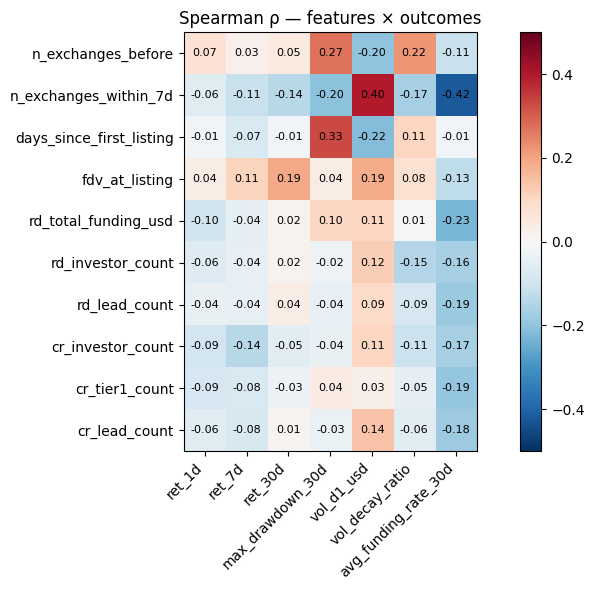

,ret_1d,ret_7d,ret_30d,max_drawdown_30d,vol_d1_usd,vol_decay_ratio,avg_funding_rate_30d
n_exchanges_before,0.070816,0.026684,0.049535,0.271525,-0.199642,0.220563,-0.113104
n_exchanges_within_7d,-0.060082,-0.109631,-0.137773,-0.203929,0.396301,-0.167641,-0.421862
days_since_first_listing,-0.011780,-0.074795,-0.013334,0.329935,-0.215110,0.107331,-0.014351
fdv_at_listing,0.038505,0.112230,0.190317,0.035783,0.186949,0.075414,-0.126014
rd_total_funding_usd,-0.099485,-0.042974,0.017267,0.102271,0.108898,0.006283,-0.229462
rd_investor_count,-0.064065,-0.041543,0.016245,-0.024130,0.123605,-0.148083,-0.164512
rd_lead_count,-0.036931,-0.041242,0.036746,-0.039614,0.094935,-0.085009,-0.185684
cr_investor_count,-0.093969,-0.139954,-0.053165,-0.035626,0.106162,-0.105939,-0.167020
cr_tier1_count,-0.085272,-0.075915,-0.027554,0.042910,0.031138,-0.049898,-0.194205
cr_lead_count,-0.060435,-0.079003,0.012768,-0.032521,0.140738,-0.057430,-0.182720


In [6]:
features = ['n_exchanges_before','n_exchanges_within_7d','days_since_first_listing',
            'fdv_at_listing','rd_total_funding_usd','rd_investor_count','rd_lead_count',
            'cr_investor_count','cr_tier1_count','cr_lead_count']
outcomes = ['ret_1d','ret_7d','ret_30d','max_drawdown_30d','vol_d1_usd',
            'vol_decay_ratio','avg_funding_rate_30d']
sub = core[features + outcomes].copy()
# log-transform skewed money columns
for col in ['fdv_at_listing','rd_total_funding_usd','vol_d1_usd']:
    sub[col] = np.log1p(sub[col])
corr = sub.corr(method='spearman').loc[features, outcomes]
import matplotlib
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(outcomes))); ax.set_xticklabels(outcomes, rotation=45, ha='right')
ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(outcomes)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax); plt.title('Spearman ρ — features × outcomes'); plt.tight_layout(); plt.show()
corr

### How to read Chart 3 (the Spearman heatmap) — the headline chart

This is the single most important picture in the analysis. Each cell is the Spearman correlation between one "before" feature (rows) and one "after" outcome (columns). The number inside is ρ (rho), ranging from −0.5 (strong inverse, deep blue) through 0 (no relationship, white) to +0.5 (strong direct, deep red).

**How to read a single cell:**
- **Top row × column `vol_decay_ratio`** shows ρ between `n_exchanges_before` and volume sustain. That number is around +0.22 — biggest red square in the matrix. It says: tokens already on more venues retain volume better.
- **Column `ret_30d`, row `fdv_at_listing`** is the +0.19 we keep mentioning — higher FDV → higher 30-day return.
- **The `vol_decay_ratio` column** is the most colorful. Several features have meaningful effects on whether the perp keeps volume.
- **The `rd_total_funding_usd` row** is mostly pale — funding USD doesn't predict any outcome much.

**What to look for:**
- The deepest red and deepest blue squares are the strongest signals.
- White squares = no relationship.
- The sign matters: red = positive (both move together), blue = inverse (one up, the other down).

**Caveat:** these are bivariate — they ignore that FDV and exchange count are themselves correlated (big tokens get listed more places). Section 6 (OLS regression) tries to disentangle that.


## 5. Targeted slices

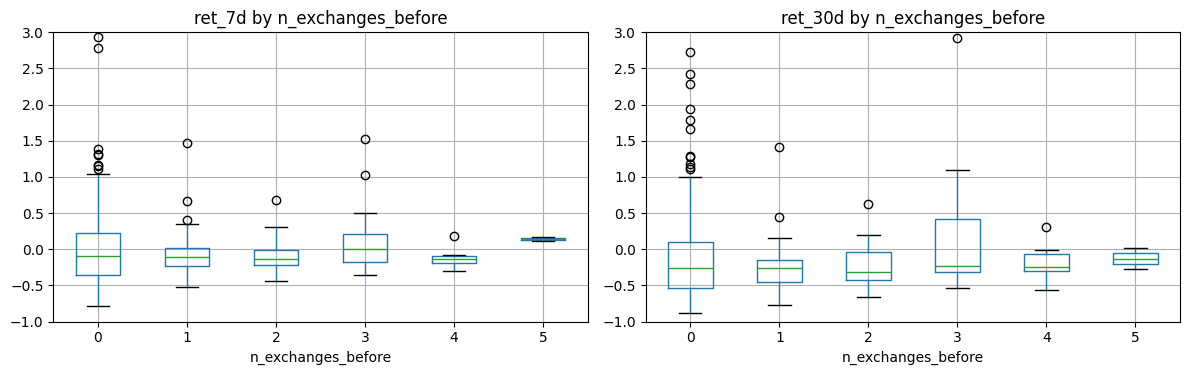

In [7]:
# 5a. Returns by exchange-footprint bucket
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
core.boxplot(column='ret_7d', by='n_exchanges_before', ax=axes[0]); axes[0].set_ylim(-1, 3); axes[0].set_title('ret_7d by n_exchanges_before')
core.boxplot(column='ret_30d', by='n_exchanges_before', ax=axes[1]); axes[1].set_ylim(-1, 3); axes[1].set_title('ret_30d by n_exchanges_before')
plt.suptitle(''); plt.tight_layout(); plt.show()

### How to read Chart 4 (returns by exchange-footprint bucket)

Two side-by-side **boxplots**. Boxplot anatomy: the orange line is the median, the box is the middle 50% of tokens, the whiskers reach out to the rest, and circles are outliers.

- **Left panel: `ret_7d` by `n_exchanges_before`.** X-axis groups tokens by how many other venues they were on before the Binance perp (0, 1, 2, 3, 4, 5). The median line should drift sideways — 7-day returns barely depend on prior exchange count.
- **Right panel: `ret_30d` by `n_exchanges_before`.** Same idea, 30-day return. Wider box = more uncertainty in that bucket.

**What to look for:**
- A median line that climbs left-to-right would mean "more prior listings → better returns" (it doesn't climb much — that finding was about *volume* sustain, not price returns).
- Tall boxes mean lots of variability in that bucket — small bucket = few tokens = noisier.

**Why these boxplots are quieter than the heatmap suggests:** the correlation matrix found `n_exchanges_before` strongly predicts `vol_decay_ratio`, NOT returns. These two panels show returns, where the signal is weak. The strong signal is in the next chart (volume bucket) and in section 5c (text output below).


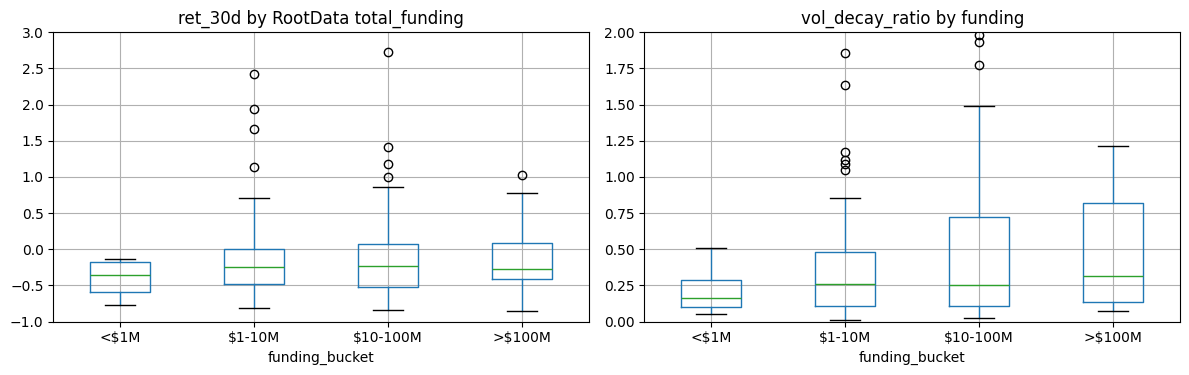

In [8]:
# 5b. Returns by funding bucket (RootData)
fund = core[core['rd_total_funding_usd'].fillna(0) > 0].copy()
fund['funding_bucket'] = pd.cut(np.log10(fund['rd_total_funding_usd']),
    bins=[-1, 6, 7, 8, 9.5], labels=['<$1M','$1-10M','$10-100M','>$100M'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fund.boxplot(column='ret_30d', by='funding_bucket', ax=axes[0]); axes[0].set_ylim(-1, 3); axes[0].set_title('ret_30d by RootData total_funding')
fund.boxplot(column='vol_decay_ratio', by='funding_bucket', ax=axes[1]); axes[1].set_ylim(0, 2); axes[1].set_title('vol_decay_ratio by funding')
plt.suptitle(''); plt.tight_layout(); plt.show()

### How to read Chart 5 (outcomes by funding bucket)

Two side-by-side boxplots. Tokens are sorted into 4 funding buckets by their RootData total: <$1M, $1–10M, $10–100M, >$100M.

- **Left panel: `ret_30d` by funding bucket.** Each box shows the 30-day return distribution for tokens in that funding range. If well-funded projects outperformed, the median line would rise left-to-right. It doesn't — confirming the heatmap's verdict that funding USD doesn't predict price return.
- **Right panel: `vol_decay_ratio` by funding bucket.** Y-axis clipped to [0, 2]. If well-funded projects sustained volume better, the median should rise. The pattern is mostly flat or slightly DECLINING — which lines up with the heatmap's finding that more investors actually correlates with *faster* fade (more hype at launch → bigger drop-off).

**What to look for:**
- Medians moving up or down across the 4 buckets = a real funding-bucket effect.
- Wide boxes in the smallest bucket (<$1M) usually mean small sample size — be skeptical of strong claims there.
- The **>$100M bucket** typically has few tokens (only the biggest projects). Its box is wide for that reason.

**Takeaway:** funding amount alone doesn't reliably predict either price return or volume sustain at this horizon. Funding *background* (number of investors) matters more than funding *size*.


In [9]:
# 5c. Did prior listing on a major CEX sustain volume?
for flag in ['had_coinbase_spot','had_okx_perp','had_binance_spot']:
    g = core.groupby(flag)['vol_decay_ratio'].agg(['median','count'])
    print(flag); print(g); print()

had_coinbase_spot
                     median  count
had_coinbase_spot                 
False              0.271445    239
True               0.303055     93

had_okx_perp
                median  count
had_okx_perp                 
False         0.265926    223
True          0.303055    109

had_binance_spot
                    median  count
had_binance_spot                 
False             0.277061    225
True              0.271445    107



## 6. OLS effect-size ranking
Not for inference (assumptions not checked) — only to compare standardized coefficients.

In [10]:
def fit(target):
    d = core[[target,'fdv_at_listing','rd_total_funding_usd','n_exchanges_before','had_coinbase_spot']].dropna()
    if len(d) < 30: return None
    X = pd.DataFrame({
        'log_fdv': np.log1p(d['fdv_at_listing']),
        'log_funding': np.log1p(d['rd_total_funding_usd']),
        'n_exch': d['n_exchanges_before'],
        'cb_spot': d['had_coinbase_spot'].astype(int),
    })
    X = (X - X.mean()) / X.std()  # standardize
    X = sm.add_constant(X)
    return sm.OLS(d[target], X).fit()

for tgt in ['ret_7d','ret_30d','vol_decay_ratio']:
    m = fit(tgt)
    if m is None: continue
    print(f'\n=== {tgt}  R²={m.rsquared:.3f}  n={int(m.nobs)} ===')
    print(m.params.round(3))
    print('p-values:'); print(m.pvalues.round(3))


=== ret_7d  R²=0.019  n=202 ===
const         -0.005
log_fdv        0.072
log_funding   -0.007
n_exch        -0.041
cb_spot        0.033
dtype: float64
p-values:
const          0.908
log_fdv        0.124
log_funding    0.888
n_exch         0.406
cb_spot        0.503
dtype: float64

=== ret_30d  R²=0.010  n=201 ===
const          0.039
log_fdv        0.214
log_funding   -0.011
n_exch        -0.055
cb_spot       -0.129
dtype: float64
p-values:
const          0.818
log_fdv        0.254
log_funding    0.955
n_exch         0.781
cb_spot        0.517
dtype: float64

=== vol_decay_ratio  R²=0.056  n=195 ===
const          0.635
log_fdv        0.061
log_funding   -0.012
n_exch        -0.159
cb_spot        0.313
dtype: float64
p-values:
const          0.000
log_fdv        0.519
log_funding    0.896
n_exch         0.111
cb_spot        0.002
dtype: float64


## 7. Findings
_Fill in after running the cells above. Read off:_
- which feature has the strongest Spearman ρ vs ret_7d / ret_30d / vol_decay_ratio
- the boxplot story for exchange-footprint and funding buckets
- the standardized OLS coefficients — biggest |β| wins
- CR ↔ RD agreement: if ρ > 0.7, treat them as concordant; otherwise list the worst disagreements